# 01 — Exploratory Data Analysis
Silver prices, macro covariates, and return series.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from eda_utils import eda_transform

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## 1. Load data

In [2]:
prices = pd.read_csv('../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
macro  = pd.read_csv('../data/raw/monthly_macro.csv', index_col=0, parse_dates=True)

silver = prices['silver'].dropna()
print(prices.shape, macro.shape)
prices.head()

(2517, 6) (2642, 6)


,silver,gold,usd_index,sp500,tip_etf,copper
Date,,,,,,
2015-01-02,15.734000,1186.000000,91.080002,2058.199951,84.513382,2.8385
2015-01-05,16.179001,1203.900024,91.379997,2020.579956,84.580849,2.7930
2015-01-06,16.603001,1219.300049,91.500000,2002.609985,84.588341,2.8040
2015-01-07,16.510000,1210.599976,91.889999,2025.900024,84.655792,2.7960
2015-01-08,16.351000,1208.400024,92.370003,2062.139893,84.520889,2.8070


## 2. Silver price level

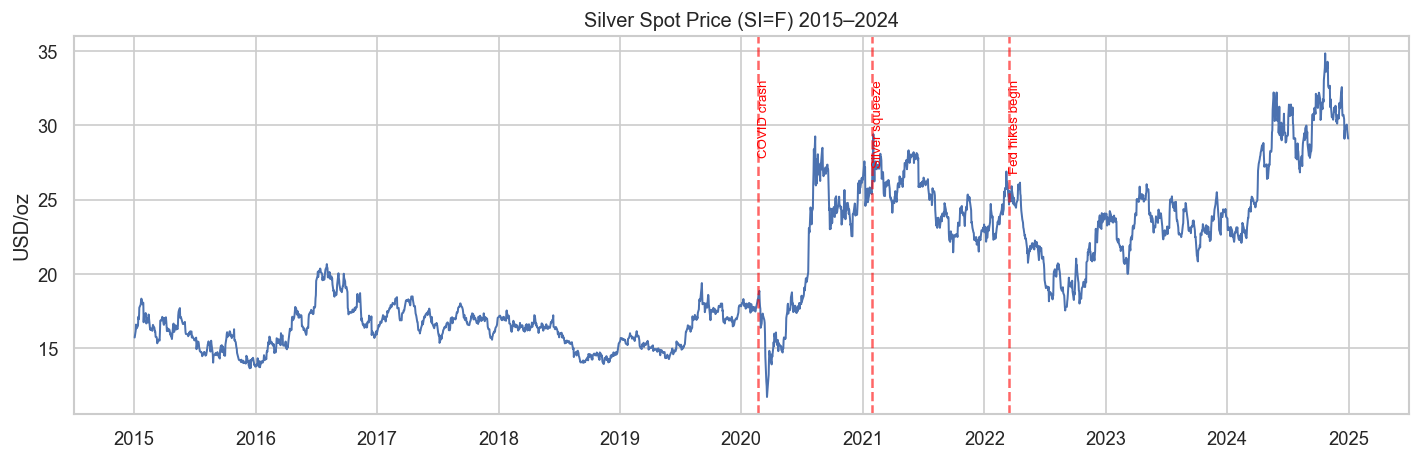

In [11]:
# Annotate key events
events = {
    'COVID crash': '2020-02-20',
    'Silver squeeze': '2021-01-28',
    'Fed hikes begin': '2022-03-16',
}

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(silver, lw=1.2, label='Silver (SI=F)')
for label, date in events.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.6)
    ax.text(pd.to_datetime(date), silver.max() * 0.95, label,
            rotation=90, fontsize=8, color='red', va='top')
ax.set_title('Silver Spot Price (SI=F) 2015–2024')
ax.set_ylabel('USD/oz')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. EDA on price level (expect non-stationary)

No transform applied.


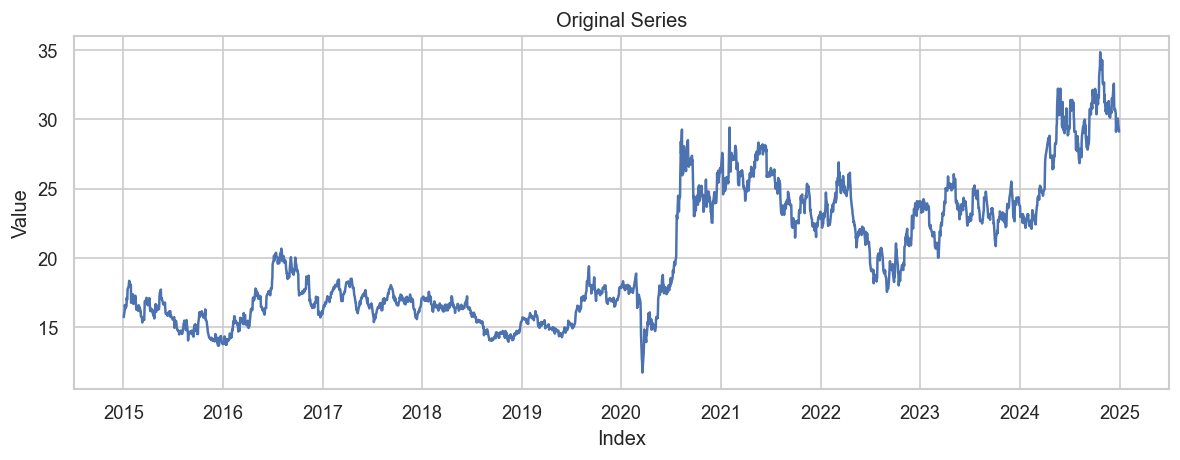

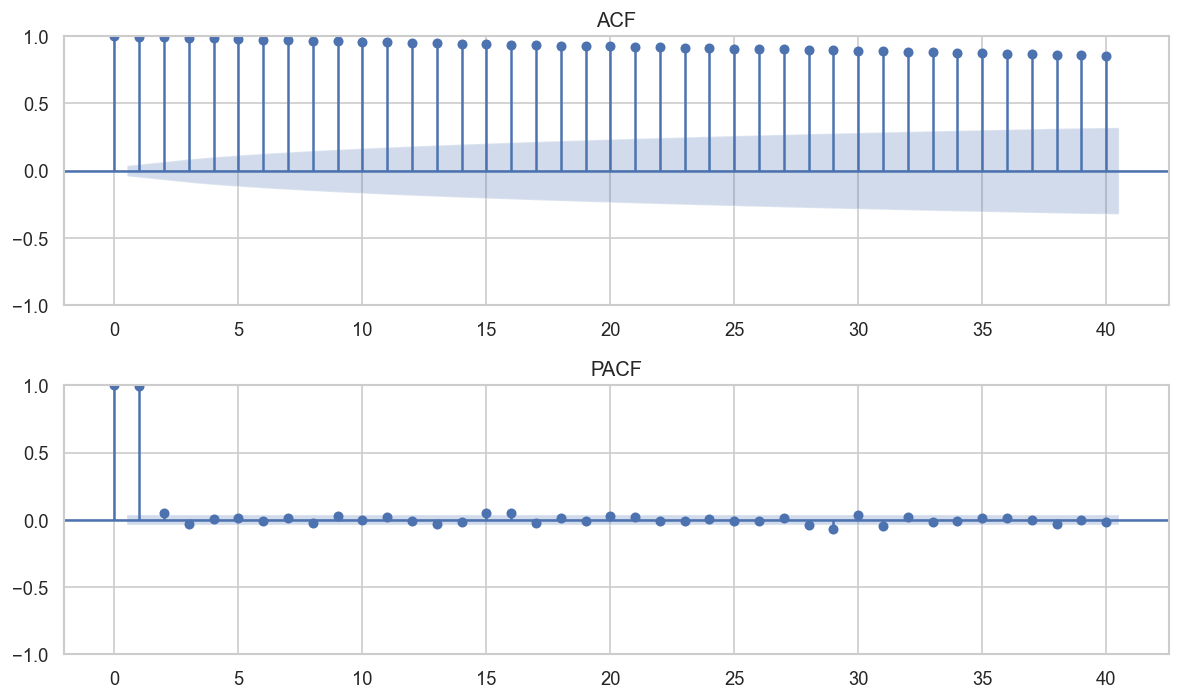

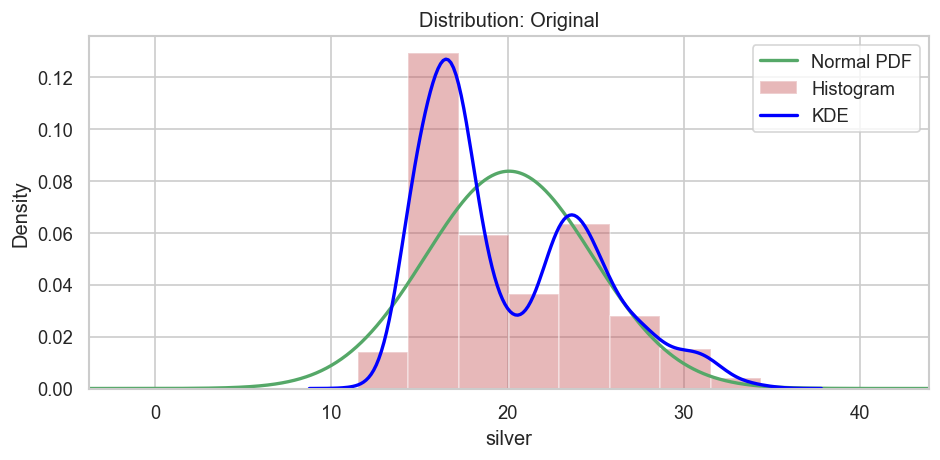

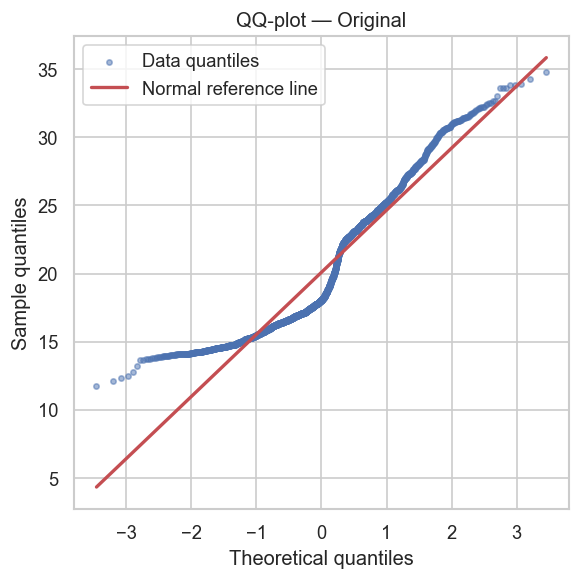

  QQ R²: 0.9153 (1.0 = perfect normal)

ADF Test:
  Statistic: -1.6324
  p-value:   0.4662
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  → Non-stationary (fail to reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.9148, p=0.0000  → NOT normal
D'Agostino K²:        stat=231.4971, p=0.0000  → NOT normal
Anderson-Darling:     stat=80.4371
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.1672, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2419.53, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [4]:
result_level = eda_transform(silver, transform=None, lags=40)

## 4. EDA on log-returns (model input)

No transform applied.


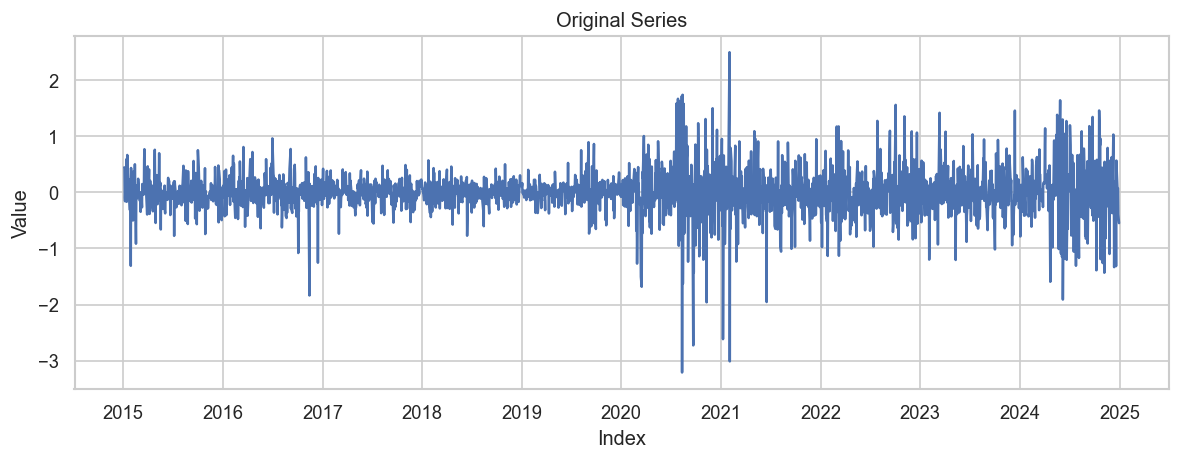

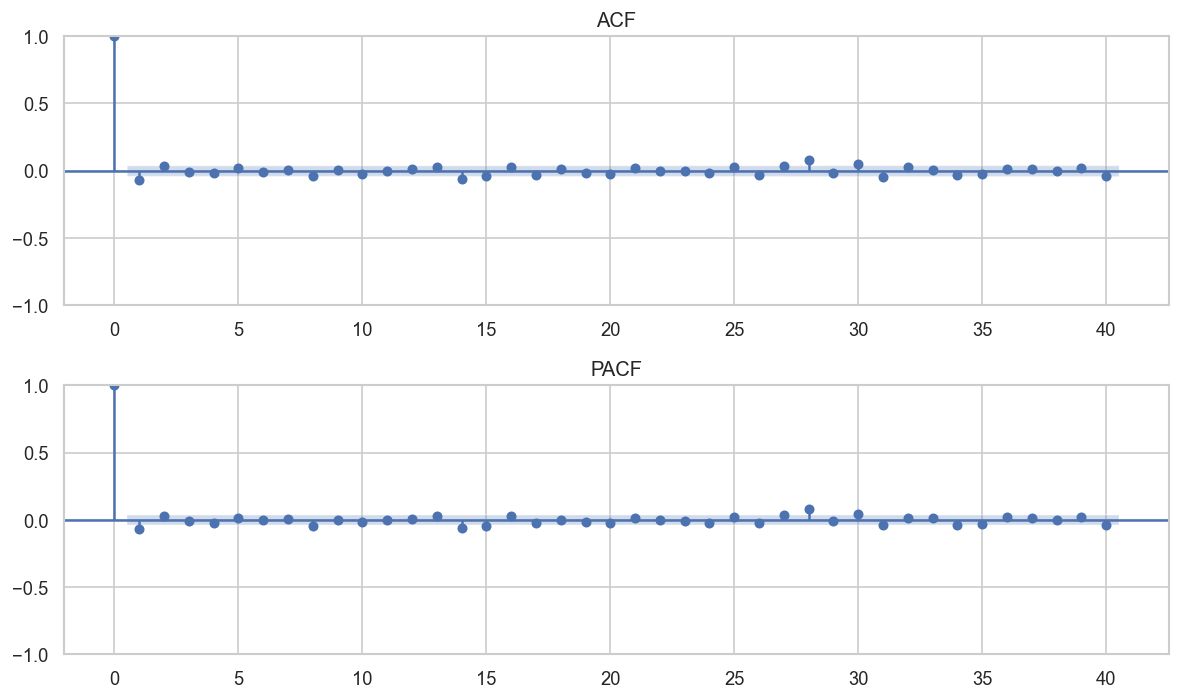

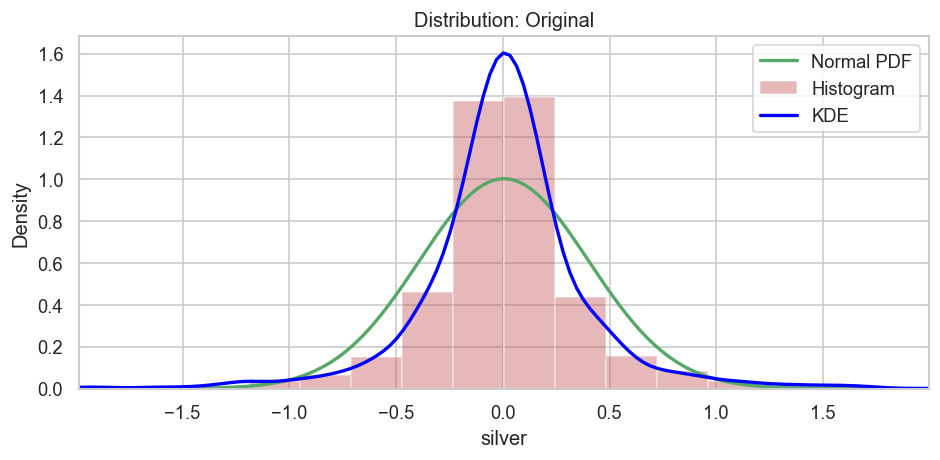

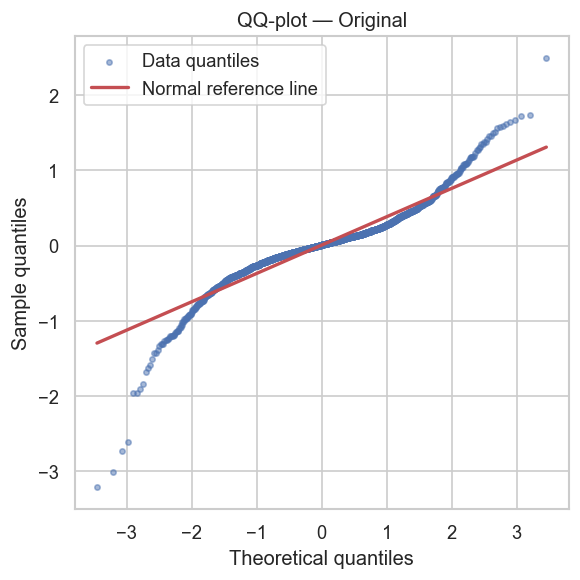

  QQ R²: 0.8959 (1.0 = perfect normal)

ADF Test:
  Statistic: -9.2475
  p-value:   0.0000
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  → Stationary (reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.8977, p=0.0000  → NOT normal
D'Agostino K²:        stat=502.5726, p=0.0000  → NOT normal
Anderson-Darling:     stat=59.5545
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.1013, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=226.26, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [4]:
result_returns = eda_transform(silver.diff().dropna(), transform=None, lags=40)

No transform applied.


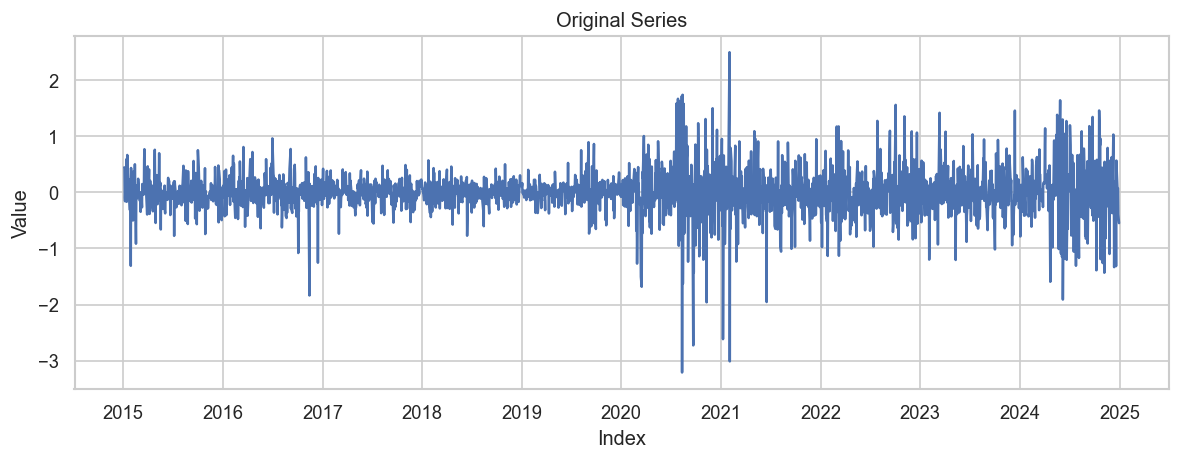

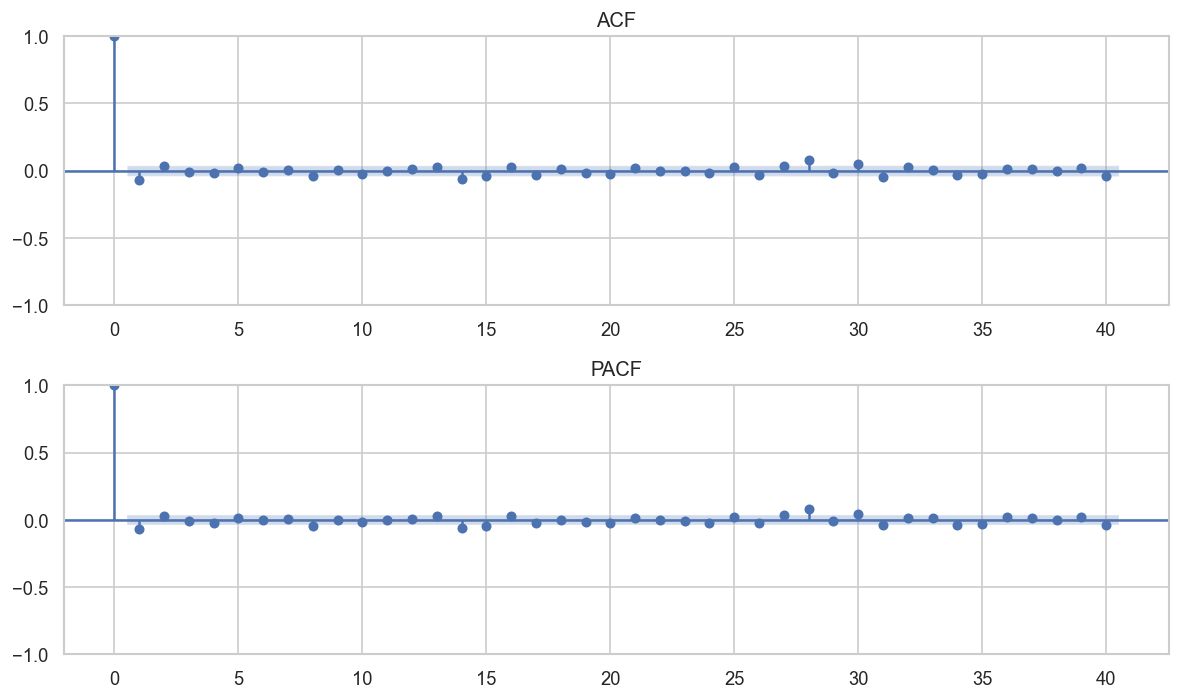

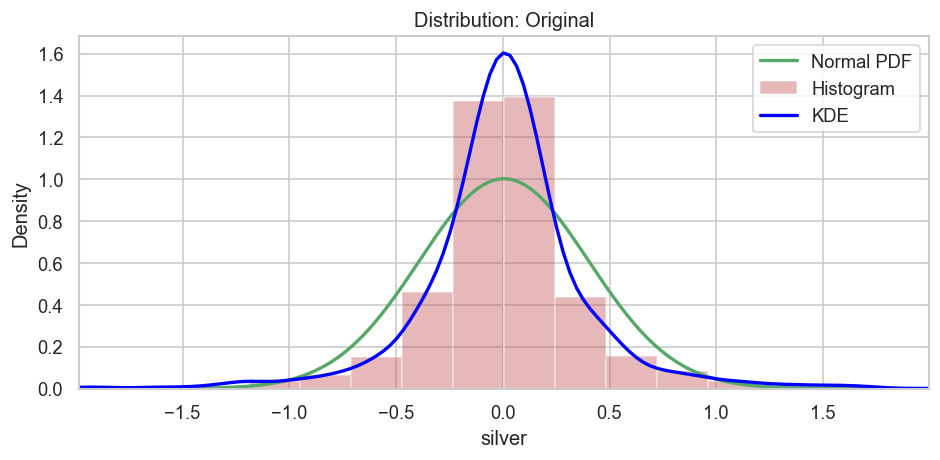

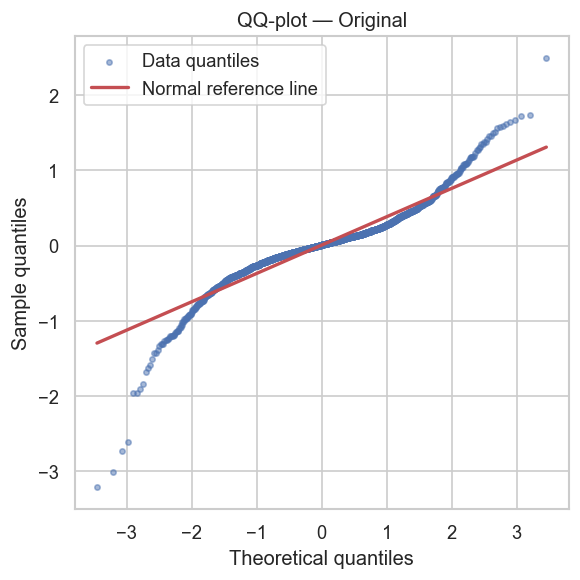

  QQ R²: 0.8959 (1.0 = perfect normal)

ADF Test:
  Statistic: -9.2475
  p-value:   0.0000
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  → Stationary (reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.8977, p=0.0000  → NOT normal
D'Agostino K²:        stat=502.5726, p=0.0000  → NOT normal
Anderson-Darling:     stat=59.5545
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.1013, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=226.26, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

In [3]:
log_price   = np.log(silver)
log_returns = log_price.diff().dropna()
log_returns.name = 'silver_log_return'

result_returns = eda_transform(silver.diff().dropna(), transform=None, lags=40)

## 5. Covariate overview

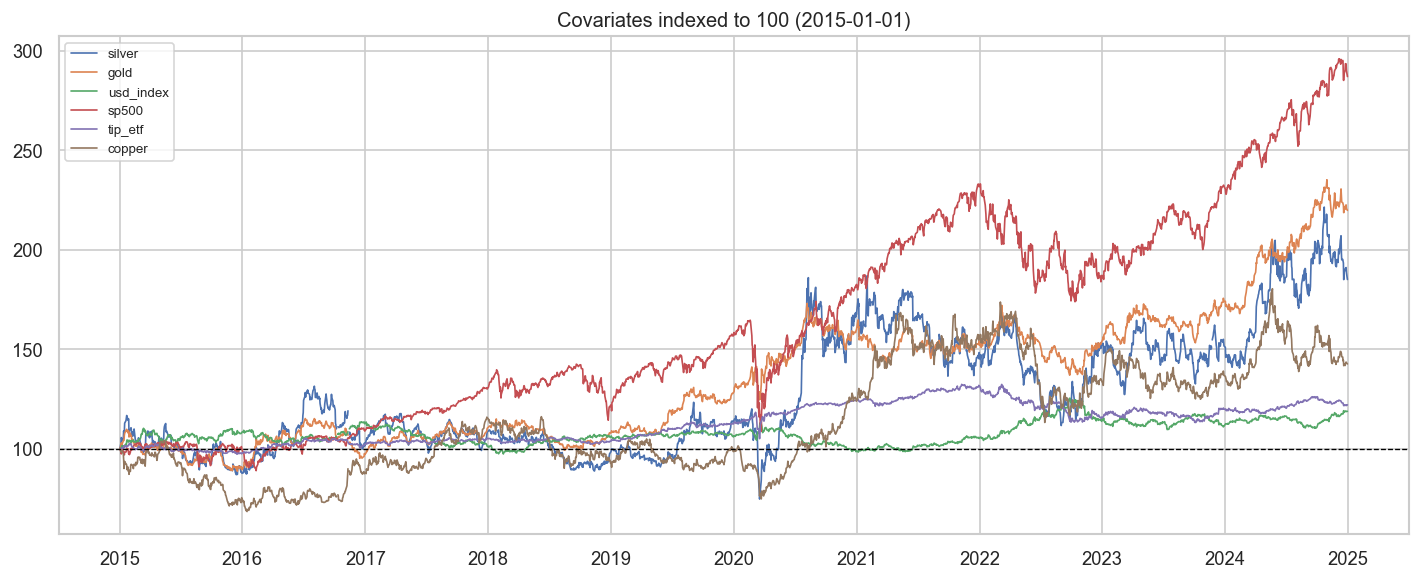

In [6]:
# Plot all daily covariates normalised to 100 at start
norm_prices = prices.div(prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for col in norm_prices.columns:
    ax.plot(norm_prices[col], label=col, lw=1)
ax.axhline(100, color='black', lw=0.8, linestyle='--')
ax.set_title('Covariates indexed to 100 (2015-01-01)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Correlation matrix

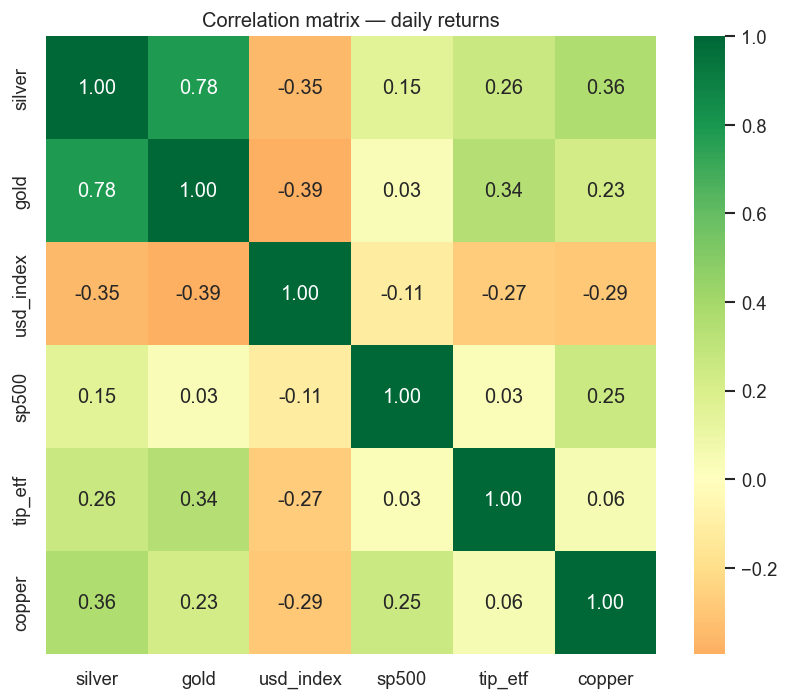

In [7]:
returns = prices.pct_change().dropna()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax)
ax.set_title('Correlation matrix — daily returns')
plt.tight_layout()
plt.show()

## 7. Gold/Silver ratio

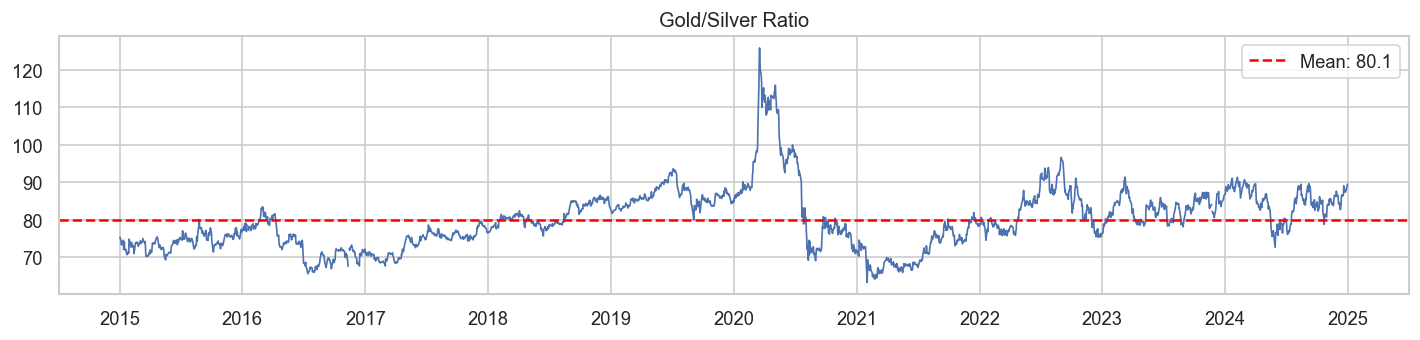

No transform applied.


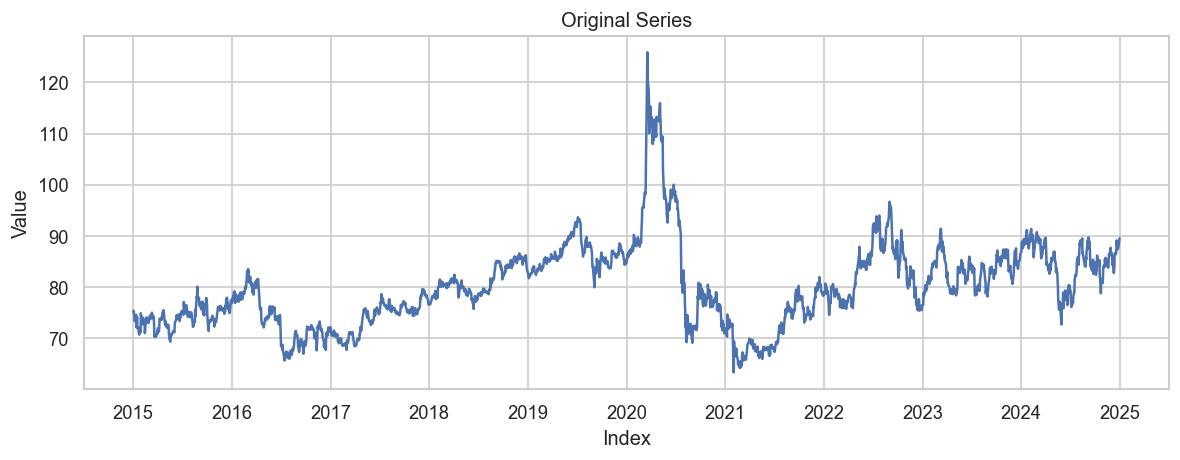

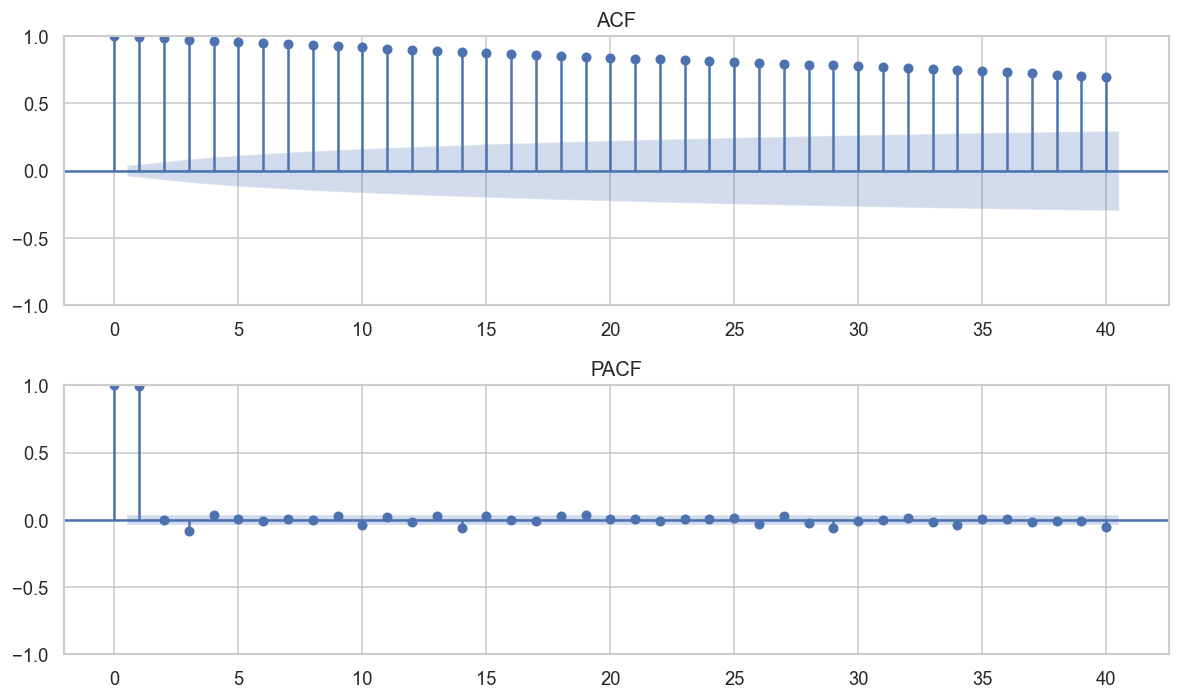

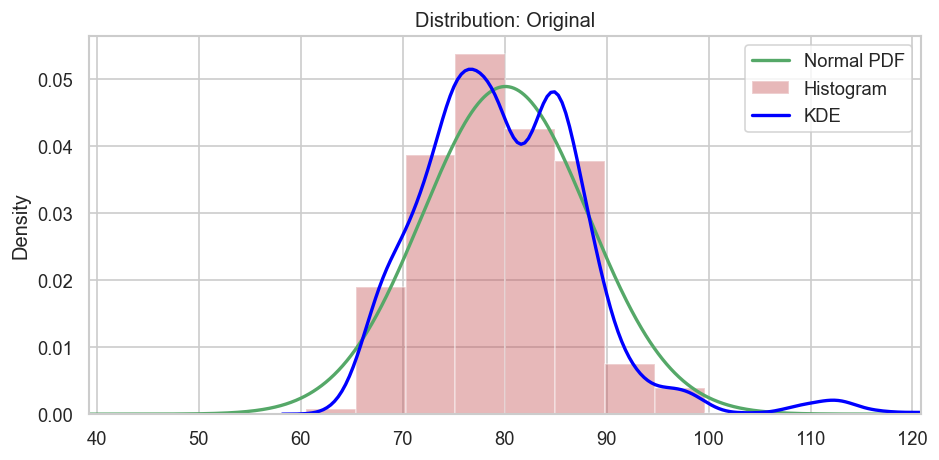

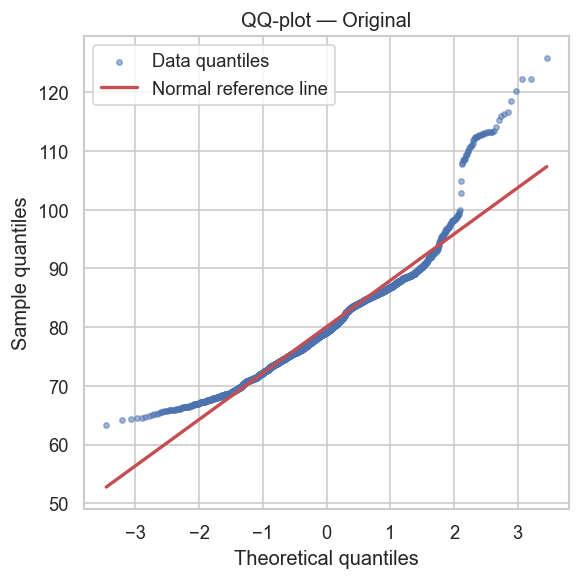

  QQ R²: 0.9341 (1.0 = perfect normal)

ADF Test:
  Statistic: -3.1978
  p-value:   0.0201
    1%: -3.4330
    5%: -2.8627
    10%: -2.5674
  → Stationary (reject H₀)

Ljung-Box (lag=40): p-value = 0.0000
  → Autocorrelation present

Shapiro-Wilk:         stat=0.9343, p=0.0000  → NOT normal
D'Agostino K²:        stat=563.5437, p=0.0000  → NOT normal
Anderson-Darling:     stat=17.6909
     15.0%: 0.5610 ← reject normality
     10.0%: 0.6310 ← reject normality
      5.0%: 0.7520 ← reject normality
      2.5%: 0.8730 ← reject normality
      1.0%: 1.0350 ← reject normality
Kolmogorov-Smirnov:   stat=0.0502, p=0.0000  → NOT normal

ARCH LM test (nlags=12):  stat=2423.34, p=0.0000
  → ARCH effects present — consider GARCH
Ljung-Box on squared (lag=40): p=0.0000
  → Autocorrelation in variance → ARCH likely


/Users/asier.ugartechegmail.com/Desktop/master/thesis/notebooks/../src/eda_utils.py:113: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_result = anderson(ts, dist='norm')
/Users/asier.ugartechegmail.com/miniforge3/envs/tf/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. fore

{'transformed_series': Date
 2015-01-02    75.378161
 2015-01-05    74.411271
 2015-01-06    73.438535
 2015-01-07    73.325255
 2015-01-08    73.903739
                 ...    
 2024-12-23    87.402971
 2024-12-24    87.409085
 2024-12-26    87.822411
 2024-12-27    88.254928
 2024-12-30    89.538240
 Length: 2512, dtype: float64,
 'adf': {'stat': -3.197754957781133,
  'pvalue': 0.020114999410551226,
  'crit': {'1%': -3.4329715599546646,
   '5%': -2.862698190651408,
   '10%': -2.567386549839784}},
 'ljung_box':          lb_stat  lb_pvalue
 40  72392.905894        0.0,
 'shapiro': {'stat': 0.9342679008031849, 'pvalue': 6.146408552229155e-32}}

In [8]:
gs_ratio = prices['gold'] / prices['silver']

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(gs_ratio, lw=1)
ax.axhline(gs_ratio.mean(), color='red', linestyle='--', label=f'Mean: {gs_ratio.mean():.1f}')
ax.set_title('Gold/Silver Ratio')
ax.legend()
plt.tight_layout()
plt.show()

# ADF on G/S ratio — often mean-reverting
eda_transform(gs_ratio.dropna(), transform=None, lags=40)

## 8. Mixed-frequency visualisation (MIDAS motivation)

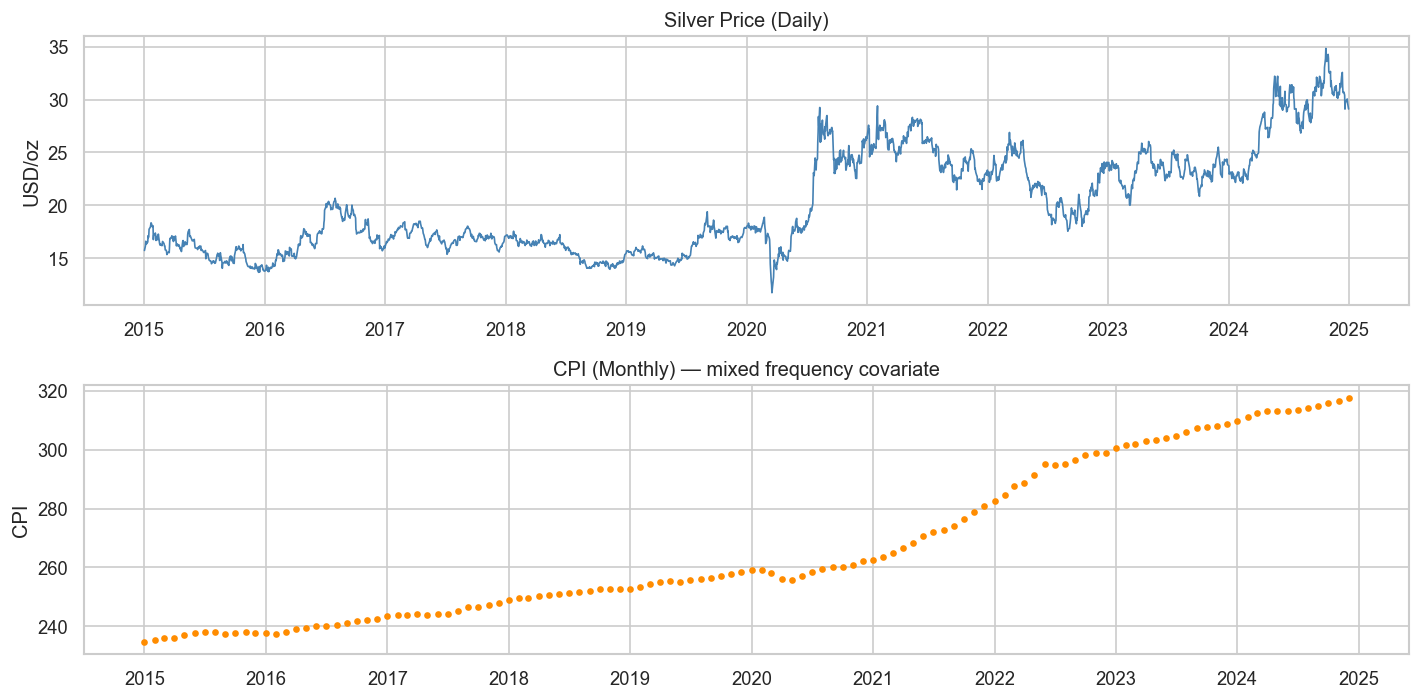

Daily obs: 2512 | Monthly obs: 2642


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

ax1.plot(silver, lw=1, color='steelblue')
ax1.set_title('Silver Price (Daily)')
ax1.set_ylabel('USD/oz')

if 'cpi' in macro.columns:
    ax2.plot(macro['cpi'], marker='o', markersize=3, lw=1, color='darkorange')
    ax2.set_title('CPI (Monthly) — mixed frequency covariate')
    ax2.set_ylabel('CPI')

plt.tight_layout()
plt.show()
print('Daily obs:', len(silver), '| Monthly obs:', len(macro))